# Premature Discretization and Posterior Uncertainty

**Claim.** Posterior uncertainty about a functional property $T(m)$ depends critically on the
geometry imposed on the model space *before* the data are observed.  A naive workflow that
discretizes $m$ into pixel vectors and equips $\mathbb{R}^N$ with the Euclidean inner product
(identity prior) does not converge to the correct continuous posterior variance as resolution
$N \to \infty$; it converges instead to a *different* answer that conflates discretization
error with prior information.

The three workflows compared in this notebook are:

| Label | Model space | Prior geometry |
|---|---|---|
| **Continuous** | $L^2(0,1)$ via intervalinf | $C_0 = (k^2 I - \alpha\Delta)^{-s/2}$ |
| **Eigenfunction truncation** *(Phase 2)* | $\mathbb{R}^N$, spanned by first $N$ eigenfunctions of $C_0$ | Spectral truncation of $C_0$ |
| **Naive identity** *(Phase 2)* | $\mathbb{R}^N$, pixel grid | $I_N$ (or $h\,I_N$ with grid spacing $h$) |

**This notebook (Phase 1)** sets up the shared continuous experiment: domain, forward operator,
scalar property functional, true model, fixed noise realization, and the continuous prior.
The resolution sweep and workflow comparisons are implemented in Phase 2.

In [ ]:
from functools import partial

from intervalinf import (IntervalDomain, BoundaryConditions, Lebesgue,

                         LebesgueIntegrationConfig, IntegrationConfig,

                         ParallelConfig)

from intervalinf.operators import (SOLAOperator, Laplacian,

                                   BesselSobolev, BesselSobolevInverse)

from intervalinf.providers import BoxCarFunctionProvider, CustomBasisProvider

from intervalinf.core.functions import Function

from intervalinf.sampling.kl_sampler import KLSampler

from pygeoinf import EuclideanSpace

from pygeoinf.gaussian_measure import GaussianMeasure

from pygeoinf.forward_problem import LinearForwardProblem

from pygeoinf.linear_bayesian import LinearBayesianInversion

from pygeoinf.linear_solvers import CholeskySolver

import numpy as np

import matplotlib.pyplot as plt


## 1. Shared Experiment Parameters

In [ ]:
# ── Domain ───────────────────────────────────────────────────────────────────

DOMAIN_A = 0.0

DOMAIN_B = 1.0



# ── Forward experiment ───────────────────────────────────────────────────────

N_d = 20

KERNEL_WIDTH = 0.10



# ── Scalar property functional ───────────────────────────────────────────────

PROP_CENTER = 0.5

PROP_WIDTH = 0.10



# ── Phase 2 resolution sweep (defined here for reference) ───────────────────

RESOLUTION_LIST = [32, 64, 128, 256, 512]



# ── Noise ────────────────────────────────────────────────────────────────────

NOISE_LEVEL = 0.05

NOISE_SEED = 42



# ── Continuous proxy (fine Lebesgue basis) ───────────────────────────────────

N_CONT = 2048



# ── Prior: C0 = (k^2 I + alpha*(-Delta))^{-s/2} with Neumann BCs ─────────────

K_PRIOR = 1.0

ALPHA_PRIOR = 1.0

S_PRIOR = 2



# ── Solver / spectral truncation used inside the continuous reference ────────

SPECTRAL_DOFS = 2048



print("Experiment parameters:")

print(f"  Domain               : [{DOMAIN_A}, {DOMAIN_B}]")

print(f"  N_d                  : {N_d}")

print(f"  Kernel width         : {KERNEL_WIDTH}")

print(f"  Property center/width: {PROP_CENTER} / {PROP_WIDTH}")

print(f"  Resolution list      : {RESOLUTION_LIST}")

print(f"  N_CONT               : {N_CONT}")

print(f"  Spectral dofs        : {SPECTRAL_DOFS}")

print(f"  Prior (k, alpha, s)  : ({K_PRIOR}, {ALPHA_PRIOR}, {S_PRIOR})")


Experiment parameters:
  Domain              : [0.0, 1.0]
  N_d                 : 20
  Kernel width        : 0.1
  Property center/width: 0.5 / 0.1
  Resolution list     : [32, 64, 128, 256, 512]
  N_CONT              : 1024
  Prior (k,alpha,s)   : (1.0, 1.0, 2)


## 2. Helper Routines

In [16]:
def gaussian_kernel(x, center, width):

    """Normalized Gaussian kernel on R."""

    return (1.0 / (width * np.sqrt(2.0 * np.pi))) * np.exp(

        -0.5 * ((x - center) / width) ** 2

    )





def make_results_container():

    """Create an empty container for the Phase-2 resolution sweep."""

    return {

        'N': [],

        'var_continuous_reference': [],

        'var_eigenf': [],

        'var_naive_id': [],

        'var_naive_scaled': [],

        'trace_eigenf': [],

        'trace_naive_id': [],

        'trace_naive_scaled': [],

    }





print("Helper routines defined: gaussian_kernel, make_results_container")


Helper routines defined: gaussian_kernel, make_results_container


## 3. Integration and Numerical Configs

In [ ]:
Lebesgue_integration_cfg = LebesgueIntegrationConfig(

    inner_product=IntegrationConfig(method='simpson', n_points=512),

    dual=IntegrationConfig(method='simpson', n_points=512),

    general=IntegrationConfig(method='simpson', n_points=1024),

)



sola_integration_cfg = IntegrationConfig(

    method='simpson',

    n_points=1024,

)



laplacian_integration_cfg = IntegrationConfig(

    method='simpson',

    n_points=1024,

)



# Keep setup robust across machines; Phase 2 can opt into more parallelism if

# a heavier sweep needs it.

parallel_cfg = ParallelConfig(

    enabled=False,

    n_jobs=1,

)



print("Integration configs created.")

print(f"  Parallel enabled: {parallel_cfg.enabled}")


Integration configs created.


## 4. Domain, Model Space, and Data Space

The continuous model space is $\mathcal{M} = L^2(0,1)$, represented numerically by a fine
pixel (boxcar) basis of dimension `N_CONT`.  The data space $\mathcal{D} = \mathbb{R}^{N_d}$
and the scalar property space $\mathcal{P} = \mathbb{R}^1$ are Euclidean.

In [ ]:
# ── Interval domain [0,1] ────────────────────────────────────────────────────

function_domain = IntervalDomain(DOMAIN_A, DOMAIN_B)



# ── Fine pixel (boxcar) basis for the continuous L2(0,1) proxy ──────────────

pixel_width = function_domain.length / N_CONT

pixel_centers = np.linspace(

    function_domain.a + pixel_width / 2,

    function_domain.b - pixel_width / 2,

    N_CONT,

)

pixel_provider = BoxCarFunctionProvider(

    function_domain,

    default_width=pixel_width,

    default_height=1.0 / np.sqrt(pixel_width),

    centers=pixel_centers,

    normalize=False,

)

basis_provider = CustomBasisProvider(

    function_domain,

    pixel_provider,

    orthonormal=True,

    basis_type='boxcar',

)



# ── Lebesgue space M = L2(0,1) (continuous proxy at N_CONT resolution) ──────

M = Lebesgue(

    N_CONT,

    function_domain,

    basis=basis_provider,

    integration_config=Lebesgue_integration_cfg,

    parallel_config=parallel_cfg,

)



# ── Data space D = R^{N_d} and scalar property space P = R^1 ────────────────

D = EuclideanSpace(N_d)

P = EuclideanSpace(1)



print(f"Model space M : L2(0,1) proxy, dimension = {M.dim}")

print(f"Data  space D : R^{D.dim}")

print(f"Prop  space P : R^{P.dim}  (scalar)")


Model space M : L2(0,1) proxy, dimension = 1024
Data  space D : R^20
Prop  space P : R^1  (scalar)


## 5. Forward Operator and Scalar Property Functional

The forward operator $G: \mathcal{M} \to \mathcal{D}$ is a SOLA operator with $N_d = 20$
Gaussian sensitivity kernels centered uniformly on $[0,1]$:

$$[G m]_i = \int_0^1 \psi_i(x)\, m(x)\, \mathrm{d}x, \qquad \psi_i(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x - c_i)^2}{2\sigma^2}\right)$$

with $\sigma = 0.1$ and centers $c_i$ spread uniformly over $[0,1]$.

The scalar property functional $T: \mathcal{M} \to \mathbb{R}$ is similarly a single integral
against a Gaussian bump at $x = 0.5$:

$$T(m) = \int_0^1 \psi_T(x)\, m(x)\, \mathrm{d}x, \qquad \psi_T(x) = \frac{1}{\sigma_T\sqrt{2\pi}} \exp\!\left(-\frac{(x - 0.5)^2}{2\sigma_T^2}\right).$$

In [ ]:
# ── Forward kernel centers: keep the Gaussian peaks inside the interval so the

# truncation at the domain boundary does not dominate the outer kernels.

forward_centers = np.linspace(

    DOMAIN_A + 0.5 * KERNEL_WIDTH,

    DOMAIN_B - 0.5 * KERNEL_WIDTH,

    N_d,

)



# ── Forward kernels as normalized Gaussian callables ────────────────────────

forward_kernel_fns = [

    partial(gaussian_kernel, center=ci, width=KERNEL_WIDTH)

    for ci in forward_centers

]



# ── SOLA forward operator G : M → D ─────────────────────────────────────────

G = SOLAOperator(

    M, D,

    kernels=forward_kernel_fns,

    integration_config=sola_integration_cfg,

    cache_kernels=True,

)



# ── Scalar property functional T : M → P (single Gaussian at 0.5) ───────────

property_kernel_fn = partial(gaussian_kernel, center=PROP_CENTER, width=PROP_WIDTH)

T = SOLAOperator(

    M, P,

    kernels=[property_kernel_fn],

    integration_config=sola_integration_cfg,

    cache_kernels=True,

)



print(f"Forward operator G : M → R^{N_d}  ({len(forward_centers)} Gaussian kernels, width={KERNEL_WIDTH})")

print(f"Property operator T : M → R^1    (Gaussian at x={PROP_CENTER}, width={PROP_WIDTH})")


Forward operator G : M → R^20  (20 Gaussian kernels, width=0.1)
Property operator T : M → R^1    (Gaussian at x=0.5, width=0.1)


## 6. True Model, Noiseless Data, and Fixed Noise Realization

The true model $\bar m$ is a sum of two Gaussian bumps at $x = 0.3$ and $x = 0.7$,
smooth enough that $G$ resolves it well with 20 kernels of width 0.1.

In [ ]:
# ── True model: sum of two smooth Gaussian bumps ──────────────────────────────

_BUMP_WIDTH = 0.08

m_true = Function(

    M,

    evaluate_callable=lambda x: (

        np.exp(-0.5 * ((x - 0.30) / _BUMP_WIDTH) ** 2)

        + 0.8 * np.exp(-0.5 * ((x - 0.70) / _BUMP_WIDTH) ** 2)

    ),

)



# ── Noiseless data and true scalar property value ────────────────────────────

d_true = G(m_true)

p_true = T(m_true)

print(f"True property value  p_true = T(m_true) = {p_true[0]:.6f}")



# ── Fixed Gaussian noise realization (reused by all workflows in Phase 2) ───

noise_sigma = NOISE_LEVEL * np.max(np.abs(d_true))

rng = np.random.default_rng(NOISE_SEED)

noise_realization = rng.standard_normal(N_d)

d_noisy = d_true + noise_sigma * noise_realization



print(f"Noiseless data range : [{d_true.min():.4f}, {d_true.max():.4f}]")

print(f"Noise sigma          : {noise_sigma:.6f}  ({NOISE_LEVEL*100:.0f}% of max signal)")

print(f"SNR                  : {np.max(np.abs(d_true)) / noise_sigma:.1f}")


True property value  p_true = T(m_true) = 0.332134
Noiseless data range : [0.0321, 0.6255]
Noise sigma          : 0.031276  (5% of max signal)
SNR                  : 20.0


## 7. Continuous Prior

We use the Whittle–Matérn / Bessel-Sobolev prior

$$C_0 = \bigl(k^2 I + \alpha(-\Delta)\bigr)^{-s/2}, \qquad k=1,\; \alpha=1,\; s=2,$$

with homogeneous Neumann boundary conditions on $[0,1]$.  The eigenvalue of $C_0$
corresponding to the $n$-th Neumann eigenfunction $\cos(n\pi x)$ (eigenvalue
$\lambda_n = (n\pi)^2$ of $-\Delta$) is

$$(k^2 + \lambda_n)^{-s/2} = (1 + n^2\pi^2)^{-1} \sim n^{-2},$$

which is summable and so $C_0$ is trace-class on $L^2(0,1)$. Samples lie in $H^1(0,1)$.

The GaussianMeasure is constructed from the spectral half-factors
$C_0^{1/2} = (k^2 I - \Delta)^{-1/2}$ (covariance factor) and
$C_0^{-1/2} = (k^2 I - \Delta)^{+1/2}$ (precision factor).

In [ ]:
# ── Laplacian L = -d^2/dx^2 with Neumann BCs ─────────────────────────────────

bc_neumann = BoundaryConditions('neumann', left=0.0, right=0.0)

laplacian_op = Laplacian(

    M,

    bc_neumann,

    alpha=ALPHA_PRIOR,

    method='spectral',

    dofs=SPECTRAL_DOFS,

)



# ── Covariance half-factor: C0^{1/2} = (k^2 I + alpha*L)^{-1/2} ─────────────

C0_half = BesselSobolevInverse(

    M, M,

    k=K_PRIOR,

    s=1.0,

    L=laplacian_op,

    dofs=SPECTRAL_DOFS,

)



# ── Precision half-factor: C0^{-1/2} = (k^2 I + alpha*L)^{+1/2} ─────────────

C0_inv_half = BesselSobolev(

    M, M,

    k=K_PRIOR,

    s=1.0,

    L=laplacian_op,

    dofs=SPECTRAL_DOFS,

)



# ── Full covariance operator: C0 = (k^2 I + alpha*L)^{-1} ───────────────────

C0_full = BesselSobolevInverse(

    M, M,

    k=K_PRIOR,

    s=float(S_PRIOR),

    L=laplacian_op,

    dofs=SPECTRAL_DOFS,

)



prior_continuous = GaussianMeasure(

    covariance_factor=C0_half,

    inverse_covariance_factor=C0_inv_half,

)



data_error_measure = GaussianMeasure.from_standard_deviations(

    D,

    noise_sigma * np.ones(N_d),

)



solver = CholeskySolver()

trace_approx = sum(C0_full.get_eigenvalue(n) for n in range(min(400, SPECTRAL_DOFS)))

print(f"Prior C0 = (k^2 I + alpha*L)^(-s/2) with (k, alpha, s)=({K_PRIOR}, {ALPHA_PRIOR}, {S_PRIOR})")

print(f"Trace(C0) ≈ {trace_approx:.4f}  (first {min(400, SPECTRAL_DOFS)} modes)")


Prior C0 = (k^2 I + L)^{-1}, k=1.0
Trace(C0) ≈ 1.1560  (first 200 modes)


## 8. Diagnostic Figure — Setup Sanity Check

Two plots confirm the problem is well-posed:

1. **Forward kernels** (thin blue lines) and the **property kernel** $\psi_T$ (thick orange), all
   plotted over $[0,1]$.  The kernels should tile the domain and the property kernel should be
   visually distinct.
2. **True model** $\bar m(x)$ and **noisy data** $\tilde d_i = d_i + \eta_i$ plotted side by side.

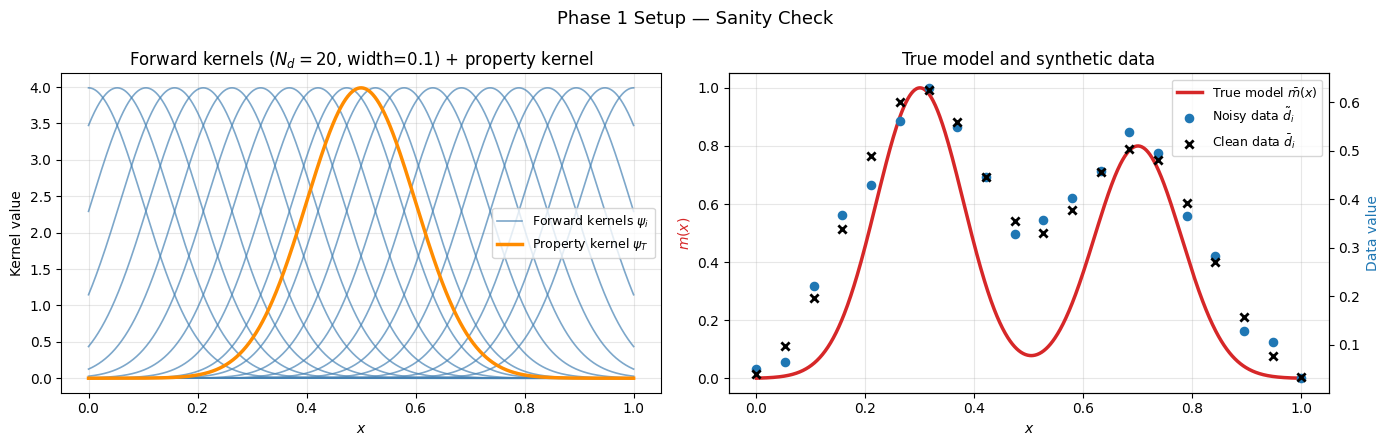

True property  p_true = 0.332134
Max forward data value: 0.6255
Noise sigma           : 3.1276e-02


In [ ]:
x_plot = np.linspace(DOMAIN_A, DOMAIN_B, 1000)



fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

fig.suptitle("Phase 1 Setup — Sanity Check", fontsize=13)



# ── Panel 1: kernels ─────────────────────────────────────────────────────────

ax = axes[0]

for i, ci in enumerate(forward_centers):

    lbl = 'Forward kernels $\\psi_i$' if i == 0 else ''

    ax.plot(x_plot, gaussian_kernel(x_plot, ci, KERNEL_WIDTH),

            color='steelblue', lw=1.2, alpha=0.7, label=lbl)

ax.plot(x_plot, gaussian_kernel(x_plot, PROP_CENTER, PROP_WIDTH),

        color='darkorange', lw=2.5, label='Property kernel $\\psi_T$')

ax.set_xlabel('$x$')

ax.set_ylabel('Kernel value')

ax.set_title(f'Forward kernels ($N_d={N_d}$, width={KERNEL_WIDTH}) + property kernel')

ax.legend(fontsize=9)

ax.grid(True, alpha=0.3)



# ── Panel 2: true model and noisy data ──────────────────────────────────────

ax = axes[1]

ax.plot(x_plot, m_true.evaluate(x_plot),

        color='tab:red', lw=2.5, label=r'True model $\bar{m}(x)$')

ax2 = ax.twinx()

ax2.scatter(forward_centers, d_noisy, s=35, color='tab:blue', zorder=4,

            label=r'Noisy data $\tilde{d}_i$')

ax2.scatter(forward_centers, d_true, s=35, color='black', marker='x',

            linewidths=2, zorder=5, label=r'Clean data $\bar{d}_i$')

ax.set_xlabel('$x$')

ax.set_ylabel('$m(x)$', color='tab:red')

ax2.set_ylabel('Data value', color='tab:blue')

ax.set_title('True model and synthetic data')

lines1, lbls1 = ax.get_legend_handles_labels()

lines2, lbls2 = ax2.get_legend_handles_labels()

ax.legend(lines1 + lines2, lbls1 + lbls2, fontsize=9, loc='upper right')

ax.grid(True, alpha=0.3)



plt.tight_layout()

plt.show()



print(f"True property  p_true = {p_true[0]:.6f}")

print(f"Max forward data value: {d_true.max():.4f}")

print(f"Noise sigma           : {noise_sigma:.4e}")


## 9. End-to-End Continuous Posterior Validation

Run the full continuous Bayesian inversion to verify the setup produces a sensible
posterior scalar property distribution.  This is the **reference result** that Phases 2
and 3 compare against.

$$\text{Posterior property variance} \quad \sigma^2_{T|d} = [T\,C_M\,T^*]_{11}$$

where $C_M = C_0 - C_0 G^*(G C_0 G^* + C_D)^{-1} G C_0$ is the model posterior covariance.

In [17]:
# ── Continuous Bayesian inversion ─────────────────────────────────────────────

forward_problem_cont = LinearForwardProblem(

    G,

    data_error_measure=data_error_measure,

)

bayes_cont = LinearBayesianInversion(forward_problem_cont, prior_continuous)



# Model posterior p(m | d_noisy)

mu_model_cont = bayes_cont.model_posterior_measure(d_noisy, solver)



# Push through scalar property functional T : M → R

mu_prop_cont = mu_model_cont.affine_mapping(operator=T)



# Scalar posterior mean and variance

p_post_mean_cont = float(mu_prop_cont.expectation[0])

C_prop_cont = mu_prop_cont.covariance.matrix(dense=True, galerkin=True)

p_post_var_cont = float(C_prop_cont[0, 0])

p_post_std_cont = float(np.sqrt(p_post_var_cont))



print("Continuous Bayesian inversion complete.")

print(f"  Posterior mean   T(m | d)    : {p_post_mean_cont:.6f}")

print(f"  Posterior std    T(m | d)    : {p_post_std_cont:.6f}")

print(f"  Posterior var    T(m | d)    : {p_post_var_cont:.6f}  ← reference for Phase 2")

print(f"  True value       T(m_true)   : {p_true[0]:.6f}")

print(f"  |mean - true| / std          : {abs(p_post_mean_cont - p_true[0]) / p_post_std_cont:.2f}  sigma")



# ── Store reference result for Phase 2 ──────────────────────────────────────

results = make_results_container()

results['var_continuous_reference'].append(p_post_var_cont)

print(f"\nReference posterior variance stored: {p_post_var_cont:.6f}")


Continuous Bayesian inversion complete.
  Posterior mean   T(m | d)    : 0.354828
  Posterior std    T(m | d)    : 0.017914
  Posterior var    T(m | d)    : 0.000321  ← reference for Phase 2
  True value       T(m_true)   : 0.332134
  |mean - true| / std          : 1.27  sigma

Reference posterior variance stored: 0.000321


---
## 10. Phase 2 — Setup: Quadrature Grid and Helper Functions

We compute the posterior property variance for three finite-dimensional workflows as
resolution $N$ varies.  All three share the same forward kernels, property kernel, and
noise level; only the model-space geometry (basis and prior) changes.

### Core formula

For a linear Gaussian model with prior $\mathbf{a} \sim \mathcal{N}(0, \mathbf{\Sigma})$
and likelihood $\mathbf{d} = \mathbf{G}\mathbf{a} + \boldsymbol{\eta}$,
$\boldsymbol{\eta} \sim \mathcal{N}(0, \sigma^2 I)$, the posterior covariance is

$$C_M = \Sigma - \Sigma G^T \underbrace{\bigl(G\Sigma G^T + \sigma^2 I\bigr)^{-1}}_{N_d \times N_d} G\Sigma$$

so the posterior property variance is $\text{var}_T = \mathbf{t}^T C_M \mathbf{t}$ and the
posterior trace is $\text{tr}(C_M) = \text{tr}(\Sigma) - \text{tr}\bigl(K^{-1}G\Sigma^2 G^T\bigr)$.

Both quantities are computed cheaply via the $N_d \times N_d$ Schur complement $K$.


In [20]:
# ── Fine midpoint-rule quadrature grid for integral evaluation ───────────────
N_QUAD = 4096
x_quad = np.linspace(0.5 / N_QUAD, 1.0 - 0.5 / N_QUAD, N_QUAD)  # midpoints
h_quad = 1.0 / N_QUAD

# Forward kernels on quadrature grid: shape (N_d, N_QUAD)
Psi_G_quad = np.vstack([
    gaussian_kernel(x_quad, ci, KERNEL_WIDTH) for ci in forward_centers
])

# Property kernel on quadrature grid: shape (N_QUAD,)
psi_T_quad = gaussian_kernel(x_quad, PROP_CENTER, PROP_WIDTH)

print(f"Quadrature grid: N_QUAD={N_QUAD}, h_quad={h_quad:.2e}")
print(f"Psi_G_quad shape: {Psi_G_quad.shape}  (N_d × N_QUAD)")


# ── Analytical Neumann eigenfunctions on [0,1] ───────────────────────────────
def neumann_eigfuncs_matrix(x: np.ndarray, N: int) -> np.ndarray:
    r"""
    Compute the first N L²-orthonormal Neumann eigenfunctions on [0,1] at x.

    The eigenfunctions of $-d^2/dx^2$ with homogeneous Neumann BCs are:

        $\phi_0(x) = 1$,
        $\phi_n(x) = \sqrt{2}\cos(n\pi x)$  for $n \ge 1$.

    Returns
    -------
    Phi : np.ndarray, shape (len(x), N)
    """
    Phi = np.empty((len(x), N), dtype=float)
    Phi[:, 0] = 1.0
    if N > 1:
        n_vec = np.arange(1, N)                         # shape (N-1,)
        Phi[:, 1:] = np.sqrt(2.0) * np.cos(            # shape (len(x), N-1)
            np.outer(x, n_vec * np.pi)
        )
    return Phi


# ── C0 eigenvalues for the truncated spectral prior ──────────────────────────
def c0_prior_eigenvalues(N: int) -> np.ndarray:
    r"""
    First N eigenvalues of $C_0 = (k^2 I + \alpha(-\Delta))^{-s/2}$ with
    Neumann BCs on [0,1], using the analytic Laplacian spectrum
    $\lambda_n = \alpha (n\pi)^2$.

    Returns
    -------
    sigma : np.ndarray, shape (N,)
        Diagonal prior covariances $\sigma_n = (k^2 + \alpha n^2\pi^2)^{-s/2}$.
    """
    n = np.arange(N, dtype=float)
    lam = ALPHA_PRIOR * (n * np.pi) ** 2               # Laplacian eigenvalues
    return (K_PRIOR ** 2 + lam) ** (-S_PRIOR / 2.0)


# ── Shared Bayesian posterior estimation (Woodbury identity) ──────────────────
def finite_dim_posterior_stats(
    G_N: np.ndarray,
    t_N: np.ndarray,
    sigma_prior: np.ndarray,
    noise_sigma: float,
) -> tuple[float, float]:
    r"""
    Posterior property variance and covariance trace for a finite-dimensional
    linear Gaussian model via the Woodbury / Schur-complement identity.

    Model: $\mathbf{d} = G_N\,\mathbf{a} + \boldsymbol{\eta}$,
    prior $\mathbf{a}\sim\mathcal{N}(0,\,\mathrm{diag}(\sigma))$,
    noise $\boldsymbol{\eta}\sim\mathcal{N}(0,\,\sigma_\text{noise}^2 I_{N_d})$.

    Parameters
    ----------
    G_N : array, shape (N_d, N)   — discretized forward operator.
    t_N : array, shape (N,)       — discretized property functional.
    sigma_prior : array, shape (N,) — diagonal prior covariances.
    noise_sigma : float             — noise standard deviation.

    Returns
    -------
    var_T : float   — posterior property variance $\mathbf{t}^T C_M \mathbf{t}$.
    trace_C_M : float — posterior covariance trace $\text{tr}(C_M)$.
    """
    N_d = G_N.shape[0]

    # G_S = G_N * diag(sigma):  G_S[i, n] = G_N[i, n] * sigma_prior[n]
    G_S = G_N * sigma_prior[np.newaxis, :]              # (N_d, N)

    # Schur complement K = G Sigma G^T + sigma_noise^2 I  (N_d × N_d)
    K = G_S @ G_N.T + (noise_sigma ** 2) * np.eye(N_d, dtype=float)
    K_inv = np.linalg.inv(K)

    # ── Posterior property variance ──
    # var_T = t^T Sigma t  −  (G Sigma t)^T K^{-1} (G Sigma t)
    prior_var_T = float(np.dot(sigma_prior * t_N, t_N))
    v = G_S @ t_N                                       # G_N Sigma t_N, (N_d,)
    var_T = prior_var_T - float(v @ (K_inv @ v))

    # ── Posterior covariance trace ──
    # tr(C_M) = tr(Sigma) − tr(K^{-1} G Sigma^2 G^T)
    G_S2 = G_N * (sigma_prior ** 2)[np.newaxis, :]      # G_N Sigma^2, (N_d, N)
    trace_CM = float(np.sum(sigma_prior) - np.trace(K_inv @ (G_S2 @ G_N.T)))

    return var_T, trace_CM


print("Helper functions defined:")
print("  neumann_eigfuncs_matrix, c0_prior_eigenvalues, finite_dim_posterior_stats")


Quadrature grid: N_QUAD=4096, h_quad=2.44e-04
Psi_G_quad shape: (20, 4096)  (N_d × N_QUAD)
Helper functions defined:
  neumann_eigfuncs_matrix, c0_prior_eigenvalues, finite_dim_posterior_stats


## 11. Phase 2 — Resolution Sweep

For each $N \in \{32, 64, 128, 256, 512\}$ we run all three workflows with the same
forward operator and property functional.

| Workflow | Model coords | Prior $\Sigma_N$ |
|---|---|---|
| **Eigenfunction** | First $N$ Neumann cosine modes | $\mathrm{diag}((k^2 + \alpha n^2\pi^2)^{-s/2})$ |
| **Naive identity** | Pixel grid $x_j = (j+\tfrac{1}{2})/N$ | $I_N$ |
| **Naive scaled** | Same pixel grid | $h\,I_N,\; h=1/N$ |

Forward matrix construction:
- *Eigenfunction*: $[G_N]_{in} = \int_0^1\psi_i(x)\phi_n(x)\,\mathrm{d}x$
  (midpoint quadrature on the `N_QUAD`-point grid).
- *Naive*: $[G_N]_{ij} = \psi_i(x_j)\,h$ (single quadrature weight per pixel).


In [18]:
# Re-initialize results for the full Phase-2 sweep
results = make_results_container()

print(f"{'N':>5}  {'ref':>10}  {'eigenf':>10}  {'naive_id':>10}  {'naive_scaled':>13}  "
      f"{'tr_eigenf':>11}  {'tr_naive_id':>12}")
print("-" * 85)

for N in RESOLUTION_LIST:
    h = 1.0 / N
    x_naive = np.linspace(0.5 * h, 1.0 - 0.5 * h, N)   # pixel cell-centres

    # ── Eigenfunction truncation workflow ─────────────────────────────────────
    # Phi: (N_QUAD, N)  columns = first N Neumann eigenfunctions at quadrature pts
    Phi = neumann_eigfuncs_matrix(x_quad, N)

    # Forward matrix:  G_eigenf[i, n] = ∫ ψ_i(x) φ_n(x) dx  ≈  Σ_k ψ_i(x_k) φ_n(x_k) h_quad
    G_eigenf = Psi_G_quad @ Phi * h_quad                  # (N_d, N)

    # Property vector: t_eigenf[n] = ∫ ψ_T(x) φ_n(x) dx
    t_eigenf = psi_T_quad @ Phi * h_quad                  # (N,)

    # Diagonal prior covariance: σ_n = (k² + α n² π²)^{-s/2}
    sigma_eigenf = c0_prior_eigenvalues(N)                 # (N,)

    var_eigenf, trace_eigenf = finite_dim_posterior_stats(
        G_eigenf, t_eigenf, sigma_eigenf, noise_sigma
    )

    # ── Naive identity-prior workflow ─────────────────────────────────────────
    # Forward matrix:  G_naive[i, j] = ψ_i(x_j) h  (pixel quadrature weight)
    G_naive = np.vstack([
        gaussian_kernel(x_naive, ci, KERNEL_WIDTH) for ci in forward_centers
    ]) * h                                                  # (N_d, N)

    # Property vector: t_naive[j] = ψ_T(x_j) h
    t_naive = gaussian_kernel(x_naive, PROP_CENTER, PROP_WIDTH) * h   # (N,)

    var_naive_id, trace_naive_id = finite_dim_posterior_stats(
        G_naive, t_naive, np.ones(N), noise_sigma
    )

    # ── Naive scaled-identity prior workflow (h · I_N) ────────────────────────
    var_naive_scaled, trace_naive_scaled = finite_dim_posterior_stats(
        G_naive, t_naive, np.full(N, h), noise_sigma
    )

    # ── Store ─────────────────────────────────────────────────────────────────
    results['N'].append(N)
    results['var_continuous_reference'].append(p_post_var_cont)
    results['var_eigenf'].append(var_eigenf)
    results['var_naive_id'].append(var_naive_id)
    results['var_naive_scaled'].append(var_naive_scaled)
    results['trace_eigenf'].append(trace_eigenf)
    results['trace_naive_id'].append(trace_naive_id)
    results['trace_naive_scaled'].append(trace_naive_scaled)

    print(f"{N:>5}  {p_post_var_cont:>10.6f}  {var_eigenf:>10.6f}  "
          f"{var_naive_id:>10.6f}  {var_naive_scaled:>13.6f}  "
          f"{trace_eigenf:>11.4f}  {trace_naive_id:>12.6f}")

print("-" * 85)
print("Phase 2 sweep complete.")


    N         ref      eigenf    naive_id   naive_scaled    tr_eigenf   tr_naive_id
-------------------------------------------------------------------------------------
   32    0.000321    0.000321    0.000410       0.000266       0.0142     23.284758
   64    0.000321    0.000321    0.000386       0.000185       0.0158     55.827759
  128    0.000321    0.000321    0.000360       0.000097       0.0166    120.418344
  256    0.000321    0.000321    0.000332       0.000036       0.0170    249.058328
  512    0.000321    0.000321    0.000301       0.000010       0.0172    505.757324
-------------------------------------------------------------------------------------
Phase 2 sweep complete.


## 12. Phase 2 — Numerical Results Summary

The table below collects all four posterior property variances alongside the posterior
covariance trace diagnostics.  Key things to check:

- **Eigenfunction** variance should approach the continuous reference from below as
  $N$ grows (spectral truncation removes prior mass in high modes, slightly tightening
  the posterior; the gap should close monotonically).
- **Naive identity** variance should decrease toward zero as $N$ grows — a spurious
  collapse caused by the identity prior's pixel-amplitude variance not scaling with $h$.
- **Naive scaled** variance (prior $h I_N$) also goes to zero, just faster.


In [19]:
import pandas as pd

# ── Build summary dataframe ───────────────────────────────────────────────────
df = pd.DataFrame({
    'N':                   results['N'],
    'var_continuous':      results['var_continuous_reference'],
    'var_eigenf':          results['var_eigenf'],
    'err_eigenf':          [abs(ve - vc) / vc for ve, vc in
                            zip(results['var_eigenf'],
                                results['var_continuous_reference'])],
    'var_naive_id':        results['var_naive_id'],
    'var_naive_scaled':    results['var_naive_scaled'],
    'trace_eigenf':        results['trace_eigenf'],
    'trace_naive_id':      results['trace_naive_id'],
    'trace_naive_scaled':  results['trace_naive_scaled'],
})

# Pretty print
pd.set_option('display.float_format', '{:.6g}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
print("Phase 2 resolution sweep — posterior property variances\n")
print(df.to_string(index=False))

# ── Sanity checks ─────────────────────────────────────────────────────────────
cont_ref = p_post_var_cont
eigenf_at_max_N = results['var_eigenf'][-1]      # N=512
naive_id_at_min_N = results['var_naive_id'][0]   # N=32

print(f"\nContinuous reference                  : {cont_ref:.6f}")
print(f"Eigenfunction at N=512               : {eigenf_at_max_N:.6f}  "
      f"(rel. err {abs(eigenf_at_max_N - cont_ref)/cont_ref:.4%})")
print(f"Naive identity at N=32               : {naive_id_at_min_N:.6f}")
print(f"Naive identity at N=512              : {results['var_naive_id'][-1]:.6f}  "
      f"← should be smaller (spurious collapse)")

# Check monotonicity of eigenfunction convergence
eigenf_diffs = [results['var_eigenf'][i+1] - results['var_eigenf'][i]
                for i in range(len(RESOLUTION_LIST) - 1)]
if all(d >= -1e-10 for d in eigenf_diffs):
    print("\nEigenfunction variances non-decreasing in N ✓  (monotone convergence)")
else:
    print("\nNote: eigenfunction variances are not strictly monotone (may be numerical noise).")

# Check naive collapse
naive_id = results['var_naive_id']
if naive_id[-1] < naive_id[0]:
    print("Naive-identity variances decrease with N ✓  (confirms spurious collapse)")
else:
    print("Note: naive-identity variances did not visibly collapse — check parameters.")


Phase 2 resolution sweep — posterior property variances

  N  var_continuous  var_eigenf  err_eigenf  var_naive_id  var_naive_scaled  trace_eigenf  trace_naive_id  trace_naive_scaled
 32     0.000320911 0.000320911 2.47142e-08    0.00041019       0.000266144     0.0142177         23.2848            0.829023
 64     0.000320911 0.000320911  4.0014e-08   0.000385834       0.000185043     0.0158383         55.8278            0.941995
128     0.000320911 0.000320911 3.86094e-08   0.000359778        9.7483e-05     0.0166392         120.418            0.985168
256     0.000320911 0.000320911 3.92639e-08    0.00033176       3.57629e-05     0.0170373         249.058             0.99734
512     0.000320911 0.000320911 4.04776e-08   0.000300767       1.02293e-05     0.0172358         505.757            0.999623

Continuous reference                  : 0.000321
Eigenfunction at N=512               : 0.000321  (rel. err 0.0000%)
Naive identity at N=32               : 0.000410
Naive identity at N=5